### Final Comparison and Conclusions

In this project, we explored three different approaches for classifying chest X-ray images: a custom CNN trained from scratch, a transfer learning model based on EfficientNetB0, and a patch-based RNN model.

The custom CNN provided a strong baseline and demonstrated that a model trained from scratch can learn meaningful patterns from the data. However, its performance was limited compared to transfer learning.

The transfer learning approach achieved the best overall performance. Using a pre-trained EfficientNet backbone allowed the model to leverage powerful feature representations learned from a large dataset, resulting in better generalization and higher accuracy.

The patch-based RNN model offered an alternative way of representing images as sequences. While it was an interesting experimental approach, its performance was lower compared to the convolution-based models, suggesting that preserving spatial structure through convolution is more effective for this task.

Overall, transfer learning proved to be the most effective approach for this problem, while the other methods provided valuable insights and comparison points.

#Test Environment

##Imports

In [ ]:
%%capture
!pip install ipython-autotime
%load_ext autotime

time: 295 µs (started: 2026-04-30 19:26:42 +00:00)


In [ ]:
%%capture
!pip install gdown

time: 4.46 s (started: 2026-04-30 19:26:42 +00:00)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

import gdown

time: 4.01 s (started: 2026-04-30 19:26:47 +00:00)


##Function and Preprocessing

In [ ]:
class_names_global = ['Bacterial', 'Normal', 'Viral']
label_to_index = {name: i for i, name in enumerate(class_names_global)}
index_to_label = {i: name for i, name in enumerate(class_names_global)}

time: 579 µs (started: 2026-04-30 19:26:51 +00:00)


In [ ]:
PATCH_SIZE = 16
IMG_SIZE = (224, 224)

def get_custom_cnn_prediction(model, img_path):
    img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    return img, predictions


def get_frozen_model_prediction(model, img_path):
    img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array, verbose=0)[0]
    return img, predictions


def get_finetune_model_prediction(model, img_path):
    img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array, verbose=0)[0]
    return img, predictions


def image_to_patch_sequence(img_path, target_size=IMG_SIZE, patch_size=PATCH_SIZE):
    img = load_img(img_path, color_mode='grayscale', target_size=target_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    num_samples, img_h, img_w, channels = img_array.shape
    patches_per_row = img_w // patch_size
    patches_per_col = img_h // patch_size
    num_patches = patches_per_row * patches_per_col
    patch_dim = patch_size * patch_size * channels

    x_reshaped = img_array.reshape(
        num_samples,
        patches_per_col,
        patch_size,
        patches_per_row,
        patch_size,
        channels
    )

    x_reshaped = x_reshaped.transpose(0, 1, 3, 2, 4, 5)

    x_patches = x_reshaped.reshape(
        num_samples,
        num_patches,
        patch_dim
    )

    return img, x_patches


def get_rnn_prediction(model, img_path):
    expected_dim = model.input_shape[-1]
    patch_size = int(np.sqrt(expected_dim))

    original_img, x_patches = image_to_patch_sequence(img_path, patch_size=patch_size)
    predictions = model.predict(x_patches, verbose=0)[0]

    return original_img, predictions


def plot_model_comparison(results_dict, filename):
    model_names = list(results_dict.keys())
    class_names_plot = [index_to_label[i] for i in range(len(index_to_label))]

    x = np.arange(len(model_names))
    width = 0.22

    plt.figure(figsize=(12, 6))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(class_names_plot)))

    for class_idx, class_name in enumerate(class_names_plot):
        probs = [results_dict[model][class_idx] * 100 for model in model_names]

        bars = plt.bar(
            x + class_idx * width,
            probs,
            width=width,
            label=class_name,
            color=colors[class_idx],
            edgecolor='black',
            linewidth=1
        )

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 1,
                f"{height:.1f}%",
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.xticks(x + width, model_names, rotation=15)
    plt.ylabel("Probability (%)")
    plt.xlabel("Models")
    plt.title(f"Predictions by Model for: {filename}")
    plt.ylim(0, 105)
    plt.legend(title="Classes")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def print_prediction_summary(results_dict):
    print("\nPrediction summary:")
    print("=" * 60)

    for model_name, probs in results_dict.items():
        pred_idx = np.argmax(probs)
        pred_label = index_to_label[pred_idx]
        confidence = probs[pred_idx] * 100

        print(f"{model_name}:")
        print(f"Predicted class: {pred_label}")
        print(f"Confidence: {confidence:.2f}%")

        for i, prob in enumerate(probs):
            print(f"  {index_to_label[i]}: {prob*100:.2f}%")
        print("-" * 40)


time: 3.61 ms (started: 2026-04-30 19:26:51 +00:00)


##Download trained models from Google Drive

In [ ]:
os.makedirs("models", exist_ok=True)

time: 468 µs (started: 2026-04-30 19:26:51 +00:00)


In [ ]:
def download_if_not_exists(url, output):
    if not os.path.exists(output):
        print(f"Downloading {output}...")
        gdown.download(url, output, quiet=False)
    else:
        print(f"{output} already exists, skipping download.")

time: 482 µs (started: 2026-04-30 19:26:51 +00:00)


In [ ]:
print("Preparing models...")

download_if_not_exists(
    "https://drive.google.com/uc?id=1jYIWc_78Dx-paVk0TTEzGNAJ71uEznjA",
    "models/cnn_model.keras"
)

download_if_not_exists(
    "https://drive.google.com/uc?id=1Wgb3HNCnmjM0OrVYIFkLqFlbyDVm_Pl9",
    "models/frozen_model.keras"
)

download_if_not_exists(
    "https://drive.google.com/uc?id=1gpVhyr_G0qewKBMmnaDzdCt4oM61_Oyn",
    "models/finetune_model.keras"
)

download_if_not_exists(
    "https://drive.google.com/uc?id=1Of1a17XBgDjYGIXSLzyuCBaPQnxhI1fc",
    "models/rnn_model.keras"
)

print("Models are ready!")

Preparing models...


Downloading...
From (original): https://drive.google.com/uc?id=1jYIWc_78Dx-paVk0TTEzGNAJ71uEznjA
From (redirected): https://drive.google.com/uc?id=1jYIWc_78Dx-paVk0TTEzGNAJ71uEznjA&confirm=t&uuid=62521c67-31d7-48c2-9c30-b3fca99c3379
To: /content/models/cnn_model.keras
100%|██████████| 159M/159M [00:02<00:00, 78.4MB/s]


Downloading...
From: https://drive.google.com/uc?id=1Wgb3HNCnmjM0OrVYIFkLqFlbyDVm_Pl9
To: /content/models/frozen_model.keras
100%|██████████| 21.4M/21.4M [00:00<00:00, 70.3MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1gpVhyr_G0qewKBMmnaDzdCt4oM61_Oyn
From (redirected): https://drive.google.com/uc?id=1gpVhyr_G0qewKBMmnaDzdCt4oM61_Oyn&confirm=t&uuid=2323bdf3-f5e9-40b4-923a-25052e675a40
To: /content/models/finetune_model.keras
100%|██████████| 41.5M/41.5M [00:00<00:00, 87.9MB/s]


Downloading...
From: https://drive.google.com/uc?id=1Of1a17XBgDjYGIXSLzyuCBaPQnxhI1fc
To: /content/models/rnn_model.keras
100%|██████████| 1.83M/1.83M [00:00<00:00, 215MB/s]

Models are ready!
time: 9.46 s (started: 2026-04-30 19:26:51 +00:00)


In [ ]:
for path in [
    "models/cnn_model.keras",
    "models/frozen_model.keras",
    "models/finetune_model.keras",
    "models/rnn_model.keras"
]:
    assert os.path.exists(path), f"{path} not found!"

print("All models verified successfully!")

All models verified successfully!
time: 824 µs (started: 2026-04-30 19:27:00 +00:00)


##Load Saved Models

In [ ]:
cnn_model_path = "models/cnn_model.keras"
cnn_model = keras.models.load_model(cnn_model_path, compile=False)

frozen_model_path = "models/frozen_model.keras"
frozen_model = keras.models.load_model(frozen_model_path, compile=False)

finetune_model_path = "models/finetune_model.keras"
finetune_model = keras.models.load_model(finetune_model_path, compile=False)

rnn_model_path = "models/rnn_model.keras"
rnn_model = keras.models.load_model(rnn_model_path, compile=False)

time: 6.47 s (started: 2026-04-30 19:27:00 +00:00)


##Upload IMG and Run All Models

Saving IM-0010-0001.jpeg to IM-0010-0001.jpeg

Running predictions for: IM-0010-0001.jpeg


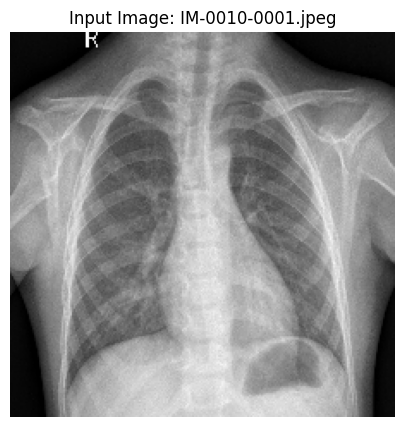

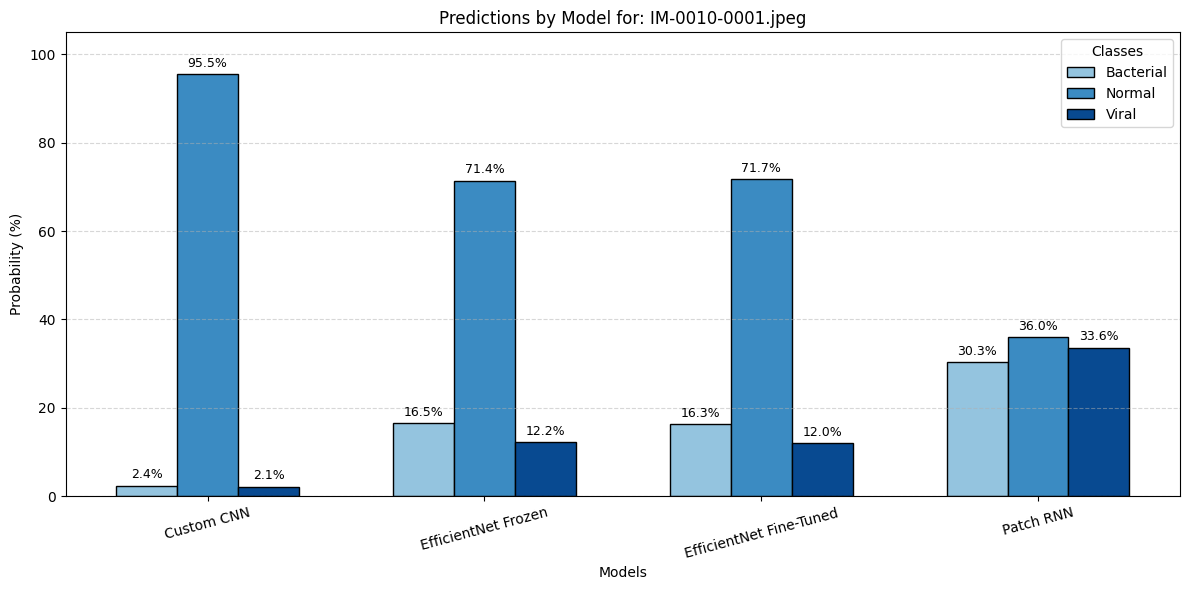


Prediction summary:
Custom CNN:
Predicted class: Normal
Confidence: 95.48%
  Bacterial: 2.37%
  Normal: 95.48%
  Viral: 2.15%
----------------------------------------
EfficientNet Frozen:
Predicted class: Normal
Confidence: 71.37%
  Bacterial: 16.47%
  Normal: 71.37%
  Viral: 12.16%
----------------------------------------
EfficientNet Fine-Tuned:
Predicted class: Normal
Confidence: 71.70%
  Bacterial: 16.27%
  Normal: 71.70%
  Viral: 12.03%
----------------------------------------
Patch RNN:
Predicted class: Normal
Confidence: 36.03%
  Bacterial: 30.34%
  Normal: 36.03%
  Viral: 33.64%
----------------------------------------
time: 1min 5s (started: 2026-04-30 19:27:07 +00:00)


In [ ]:
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nRunning predictions for: {filename}")
    print("=" * 60)

    display_img, cnn_preds = get_custom_cnn_prediction(cnn_model, filename)
    _, frozen_preds = get_frozen_model_prediction(frozen_model, filename)
    _, finetune_preds = get_finetune_model_prediction(finetune_model, filename)
    _, rnn_preds = get_rnn_prediction(rnn_model, filename)

    plt.figure(figsize=(5, 5))
    plt.imshow(display_img)
    plt.title(f"Input Image: {filename}")
    plt.axis("off")
    plt.show()

    results = {
        "Custom CNN": cnn_preds,
        "EfficientNet Frozen": frozen_preds,
        "EfficientNet Fine-Tuned": finetune_preds,
        "Patch RNN": rnn_preds
    }

    plot_model_comparison(results, filename)
    print_prediction_summary(results)